# Análisis de datos de accidentalidad en Barranquilla

1. Importación de librerías y clases

In [1]:
import sys
import pandas as pd

sys.path.append("..")

from src.accidentes import Accidentes
from src.precipitacion import Precipitacion
from src.comparendos import Comparendos


2. Dataset de accidentalidad

2.1 Carga de los datos

In [30]:
accidentes = Accidentes(
    "../dataset/Accidentalidad_en_Barranquilla_20260830.csv"
)

df_accidentes = accidentes.cargar()

In [31]:
df_accidentes.head()

,FECHA_ACCIDENTE,HORA_ACCIDENTE,GRAVEDAD_ACCIDENTE,CLASE_ACCIDENTE,SITIO_EXACTO_ACCIDENTE,CANT_HERIDOS_EN _SITIO_ACCIDENTE,CANT_MUERTOS_EN _SITIO_ACCIDENTE,CANTIDAD_ACCIDENTES,AÑO_ACCIDENTE,MES_ACCIDENTE,DIA_ACCIDENTE
0,2018-01-01T00:00:00.000,01:30:00:am,Con heridos,Atropello,CL 87 9H 24,1.0,NaN,1,2018,January,Mon
1,2018-01-01T00:00:00.000,02:00:00:pm,Solo daños,Choque,CL 110 CR 46,NaN,NaN,1,2018,January,Mon
2,2018-01-01T00:00:00.000,04:00:00:am,Solo daños,Choque,AV CIRCUNVALAR CR 9G,NaN,NaN,1,2018,January,Mon
3,2018-01-01T00:00:00.000,04:30:00:am,Solo daños,Choque,CLLE 72 CRA 29,NaN,NaN,1,2018,January,Mon
4,2018-01-01T00:00:00.000,05:20:00:pm,Solo daños,Choque,VIA 40 CALLE 75,NaN,NaN,1,2018,January,Mon


2.2 Diagnóstico inicial 

In [32]:
accidentes.diagnosticar()

Filas: 28523
Columnas: 11

Valores nulos:
FECHA_ACCIDENTE                         0
HORA_ACCIDENTE                          0
GRAVEDAD_ACCIDENTE                      0
CLASE_ACCIDENTE                         0
SITIO_EXACTO_ACCIDENTE                  0
CANT_HERIDOS_EN _SITIO_ACCIDENTE    15693
CANT_MUERTOS_EN _SITIO_ACCIDENTE    28186
CANTIDAD_ACCIDENTES                     0
AÑO_ACCIDENTE                           0
MES_ACCIDENTE                           0
DIA_ACCIDENTE                           0
dtype: int64

Duplicados: 0


2.3 Limpieza de datos

In [33]:
accidentes.limpiar()

,FECHA_ACCIDENTE,HORA_ACCIDENTE,GRAVEDAD_ACCIDENTE,CLASE_ACCIDENTE,SITIO_EXACTO_ACCIDENTE,CANT_HERIDOS_EN _SITIO_ACCIDENTE,CANT_MUERTOS_EN _SITIO_ACCIDENTE,CANTIDAD_ACCIDENTES,AÑO_ACCIDENTE,MES_ACCIDENTE,DIA_ACCIDENTE
0,2018-01-01T00:00:00.000,01:30:00:am,Con heridos,Atropello,CL 87 9H 24,1.0,0.0,1,2018,January,Mon
1,2018-01-01T00:00:00.000,02:00:00:pm,Solo daños,Choque,CL 110 CR 46,0.0,0.0,1,2018,January,Mon
2,2018-01-01T00:00:00.000,04:00:00:am,Solo daños,Choque,AV CIRCUNVALAR CR 9G,0.0,0.0,1,2018,January,Mon
3,2018-01-01T00:00:00.000,04:30:00:am,Solo daños,Choque,CLLE 72 CRA 29,0.0,0.0,1,2018,January,Mon
4,2018-01-01T00:00:00.000,05:20:00:pm,Solo daños,Choque,VIA 40 CALLE 75,0.0,0.0,1,2018,January,Mon
...,...,...,...,...,...,...,...,...,...,...,...
28518,2026-06-15T00:00:00.000,02:15:00:pm,Con heridos,Choque,CRA 47 CALLE 68,1.0,0.0,1,2026,June,Mon
28519,2026-06-15T00:00:00.000,08:00:00:am,Con heridos,Choque,CALLE 115 CRA 29,2.0,0.0,1,2026,June,Mon
28520,2026-06-15T00:00:00.000,11:20:00:am,Con heridos,Choque,AVENIDA VIA 40 KMT 3 LAS FLORES,1.0,0.0,1,2026,June,Mon
28521,2026-06-16T00:00:00.000,01:45:00:pm,Con heridos,Choque,CRA 57 CALLE 90,1.0,0.0,1,2026,June,Tue


In [34]:
accidentes.diagnosticar()

Filas: 28523
Columnas: 11

Valores nulos:
FECHA_ACCIDENTE                       0
HORA_ACCIDENTE                        0
GRAVEDAD_ACCIDENTE                    0
CLASE_ACCIDENTE                       0
SITIO_EXACTO_ACCIDENTE                0
CANT_HERIDOS_EN _SITIO_ACCIDENTE    223
CANT_MUERTOS_EN _SITIO_ACCIDENTE      0
CANTIDAD_ACCIDENTES                   0
AÑO_ACCIDENTE                         0
MES_ACCIDENTE                         0
DIA_ACCIDENTE                         0
dtype: int64

Duplicados: 0


2.4 Exportación del dataset limpio

In [41]:
accidentes.guardar(
    "../dataset/Accidentalidad_en_Barranquilla_limpio.csv"
)

Archivo limpio guardado correctamente.


3. Dataset de precipitación

3.1 Carga de los datos

In [2]:
precipitacion = Precipitacion(
    "../dataset/precipitacion_barranquilla.csv"
)

In [3]:
precipitacion.cargar()

,codigoestacion,codigosensor,fechaobservacion,valorobservado,nombreestacion,departamento,municipio,zonahidrografica,latitud,longitud,descripcionsensor,unidadmedida
0,29004520,240,2019-06-07T13:30:00.000,0.2,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm
1,29004520,240,2019-08-03T10:30:00.000,0.0,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm
2,29004520,240,2018-09-03T07:40:00.000,0.0,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm
3,29004520,240,2017-12-14T16:20:00.000,0.0,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm
4,29004520,240,2017-11-08T07:20:00.000,0.0,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,29004520,240,2017-11-30T06:00:00.000,0.0,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm
49996,29004520,240,2017-07-24T18:30:00.000,0.0,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm
49997,29004520,240,2017-06-21T09:20:00.000,0.0,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm
49998,29004520,240,2017-08-08T10:50:00.000,0.0,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm


3.2 Diagnóstico inicial

In [4]:
precipitacion.diagnosticar()

Filas: 50000
Columnas: 12

Valores nulos:
codigoestacion       0
codigosensor         0
fechaobservacion     0
valorobservado       0
nombreestacion       0
departamento         0
municipio            0
zonahidrografica     0
latitud              0
longitud             0
descripcionsensor    0
unidadmedida         0
dtype: int64

Duplicados: 0


3.3 Limpieza de datos

In [5]:
precipitacion.limpiar()

,codigoestacion,codigosensor,fechaobservacion,valorobservado,nombreestacion,departamento,municipio,zonahidrografica,latitud,longitud,descripcionsensor,unidadmedida
0,29004520,240,2019-06-07 13:30:00,0.2,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm
1,29004520,240,2019-08-03 10:30:00,0.0,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm
2,29004520,240,2018-09-03 07:40:00,0.0,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm
3,29004520,240,2017-12-14 16:20:00,0.0,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm
4,29004520,240,2017-11-08 07:20:00,0.0,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,29004520,240,2017-11-30 06:00:00,0.0,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm
49996,29004520,240,2017-07-24 18:30:00,0.0,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm
49997,29004520,240,2017-06-21 09:20:00,0.0,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm
49998,29004520,240,2017-08-08 10:50:00,0.0,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm


In [6]:
precipitacion.diagnosticar()

Filas: 50000
Columnas: 12

Valores nulos:
codigoestacion       0
codigosensor         0
fechaobservacion     0
valorobservado       0
nombreestacion       0
departamento         0
municipio            0
zonahidrografica     0
latitud              0
longitud             0
descripcionsensor    0
unidadmedida         0
dtype: int64

Duplicados: 0


3.4 Exportación del dataset limpio

In [7]:
precipitacion.guardar(
    "../dataset/precipitacion_barranquilla_limpio.csv"
)

Archivo limpio guardado correctamente.


4. Dataset de comparendos

4.1 Carga de los datos

In [2]:
comparendos = Comparendos(
    "../dataset/Comparendos_Barranquilla.csv"
)

In [3]:
comparendos.cargar()

,fecha_comparendo,COD_INFRACCION,DESC_INFRACCION,TIPO_INFRACCION,SERVICIO_VEHICULO_INFRACTOR,CLASE_VEHICULO_INFRACTOR,CANTIDAD_INFRACCIONES,Tipo Camara,Camara_y_direccion
0,2018 Jan 01 12:00:00 AM,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,AUTOMOVIL,4,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 31
1,2018 Jan 01 12:00:00 AM,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,CAMIONETA,2,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 31
2,2018 Jan 01 12:00:00 AM,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,CAMIONETA,1,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 31
3,2018 Jan 01 12:00:00 AM,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,AUTOMOVIL,2,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 9G
4,2018 Jan 01 12:00:00 AM,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,CAMIONETA,3,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 9G
...,...,...,...,...,...,...,...,...,...
357738,2026 Jun 30 12:00:00 AM,D04,No detenerse ante luz roja o amarilla de semáf...,TRÁNSITO,PARTICULAR,AUTOMOVIL,1,Fijo,CALLE 45 CON CARRERA 21 SENTIDO NORTE-SUR
357739,2026 Jun 30 12:00:00 AM,D04,No detenerse ante luz roja o amarilla de semáf...,TRÁNSITO,PARTICULAR,MOTOCICLETA,4,Fijo,CALLE 45 CON CARRERA 21 SENTIDO NORTE-SUR
357740,2026 Jun 30 12:00:00 AM,D04,No detenerse ante luz roja o amarilla de semáf...,TRÁNSITO,PUBLICO,AUTOMOVIL,1,Fijo,CALLE 45 CON CARRERA 21 SENTIDO NORTE-SUR
357741,2026 Jun 30 12:00:00 AM,D04,No detenerse ante luz roja o amarilla de semáf...,TRÁNSITO,PARTICULAR,AUTOMOVIL,3,Fijo,CARRERA 53 ENTRE CALLE 104 Y 106


In [4]:
comparendos.df.head()

,fecha_comparendo,COD_INFRACCION,DESC_INFRACCION,TIPO_INFRACCION,SERVICIO_VEHICULO_INFRACTOR,CLASE_VEHICULO_INFRACTOR,CANTIDAD_INFRACCIONES,Tipo Camara,Camara_y_direccion
0,2018 Jan 01 12:00:00 AM,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,AUTOMOVIL,4,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 31
1,2018 Jan 01 12:00:00 AM,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,CAMIONETA,2,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 31
2,2018 Jan 01 12:00:00 AM,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,CAMIONETA,1,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 31
3,2018 Jan 01 12:00:00 AM,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,AUTOMOVIL,2,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 9G
4,2018 Jan 01 12:00:00 AM,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,CAMIONETA,3,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 9G


4.2 Diagnóstico inicial

1. Diagnóstico general

In [5]:
comparendos.diagnosticar()

Filas: 357743
Columnas: 9

Valores nulos:
fecha_comparendo                 0
COD_INFRACCION                   0
DESC_INFRACCION                977
TIPO_INFRACCION                  0
SERVICIO_VEHICULO_INFRACTOR      0
CLASE_VEHICULO_INFRACTOR         0
CANTIDAD_INFRACCIONES            0
Tipo Camara                      0
Camara_y_direccion               0
dtype: int64

Duplicados: 127732


4.2.1 Valores únicos por columna

In [6]:
print("VALORES ÚNICOS POR COLUMNA")
print(comparendos.df.nunique())

VALORES ÚNICOS POR COLUMNA
fecha_comparendo               3085
COD_INFRACCION                    6
DESC_INFRACCION                   5
TIPO_INFRACCION                   1
SERVICIO_VEHICULO_INFRACTOR       4
CLASE_VEHICULO_INFRACTOR         15
CANTIDAD_INFRACCIONES            64
Tipo Camara                       3
Camara_y_direccion               56
dtype: int64


4.2.2 Códigos de infracción más frecuentes

In [7]:
print("CÓDIGOS DE INFRACCIÓN MÁS FRECUENTES")
print(comparendos.df["COD_INFRACCION"].value_counts().head(10))

CÓDIGOS DE INFRACCIÓN MÁS FRECUENTES
COD_INFRACCION
C02    177253
C29    125178
D04     26717
C03     24506
C32      3112
C14       977
Name: count, dtype: int64


4.2.3 Fechas más frecuentes

In [8]:
print("FECHAS MÁS FRECUENTES")
print(comparendos.df["fecha_comparendo"].value_counts().head(10))

FECHAS MÁS FRECUENTES
fecha_comparendo
2019 May 17 12:00:00 AM    264
2019 May 09 12:00:00 AM    257
2019 May 15 12:00:00 AM    255
2019 May 07 12:00:00 AM    253
2019 May 30 12:00:00 AM    248
2019 Jun 13 12:00:00 AM    240
2019 May 14 12:00:00 AM    237
2019 May 18 12:00:00 AM    233
2019 Jul 06 12:00:00 AM    232
2019 May 22 12:00:00 AM    230
Name: count, dtype: int64


4.2.4 Revisar los duplicados

In [9]:
print("DUPLICADOS EXACTOS:")
print(comparendos.df.duplicated().sum())

DUPLICADOS EXACTOS:
127732


In [10]:
print("EJEMPLOS DE DUPLICADOS:")
print(
    comparendos.df[
        comparendos.df.duplicated(keep=False)
    ].head(20)
)

EJEMPLOS DE DUPLICADOS:
            fecha_comparendo COD_INFRACCION  \
3    2018 Jan 01 12:00:00 AM            C29   
8    2018 Jan 01 12:00:00 AM            C29   
85   2018 Jan 02 12:00:00 AM            C02   
86   2018 Jan 02 12:00:00 AM            C02   
87   2018 Jan 02 12:00:00 AM            C02   
88   2018 Jan 02 12:00:00 AM            C02   
89   2018 Jan 02 12:00:00 AM            C02   
90   2018 Jan 02 12:00:00 AM            C02   
91   2018 Jan 02 12:00:00 AM            C02   
92   2018 Jan 02 12:00:00 AM            C02   
93   2018 Jan 02 12:00:00 AM            C02   
94   2018 Jan 02 12:00:00 AM            C02   
95   2018 Jan 02 12:00:00 AM            C02   
96   2018 Jan 02 12:00:00 AM            C02   
97   2018 Jan 02 12:00:00 AM            C02   
98   2018 Jan 02 12:00:00 AM            C02   
99   2018 Jan 02 12:00:00 AM            C02   
100  2018 Jan 02 12:00:00 AM            C02   
101  2018 Jan 02 12:00:00 AM            C02   
102  2018 Jan 02 12:00:00 AM        

4.2.5 Análisis de valores faltantes

In [11]:
print("REGISTROS CON DESC_INFRACCION FALTANTE")
print(
    comparendos.df[
        comparendos.df["DESC_INFRACCION"].isnull()
    ]["COD_INFRACCION"].value_counts()
)

REGISTROS CON DESC_INFRACCION FALTANTE
COD_INFRACCION
C14    977
Name: count, dtype: int64


4.2.6 Análisis de los registros C14

In [12]:
print("REGISTROS DEL CÓDIGO C14")
print(
    comparendos.df[
        comparendos.df["COD_INFRACCION"] == "C14"
    ]["DESC_INFRACCION"].value_counts(dropna=False)
)

REGISTROS DEL CÓDIGO C14
DESC_INFRACCION
NaN    977
Name: count, dtype: int64


4.2.7 Análisis de duplicados

In [13]:
print("PORCENTAJE DE DUPLICADOS:")

porcentaje = (
    comparendos.df.duplicated().sum()
    / len(comparendos.df)
) * 100

print(round(porcentaje, 2), "%")

PORCENTAJE DE DUPLICADOS:
35.7 %


4.2.8 Análisis de duplicados por código de infracción

In [14]:
print("DUPLICADOS POR CÓDIGO DE INFRACCIÓN")

duplicados = comparendos.df[
    comparendos.df.duplicated(keep=False)
]

print(
    duplicados["COD_INFRACCION"].value_counts()
)

DUPLICADOS POR CÓDIGO DE INFRACCIÓN
COD_INFRACCION
C02    155719
C29      1084
Name: count, dtype: int64


4.2.9 Comparación de registros duplicados

In [15]:
print("FRECUENCIA DE LAS FILAS DUPLICADAS")

frecuencia = comparendos.df.value_counts()

print(frecuencia.head(10))

FRECUENCIA DE LAS FILAS DUPLICADAS
fecha_comparendo         COD_INFRACCION  DESC_INFRACCION                                  TIPO_INFRACCION  SERVICIO_VEHICULO_INFRACTOR  CLASE_VEHICULO_INFRACTOR  CANTIDAD_INFRACCIONES  Tipo Camara  Camara_y_direccion     
2018 Jun 09 12:00:00 AM  C02             Estacionar un vehículo en los sitios prohibidos  TRÁNSITO         PARTICULAR                   AUTOMOVIL                 1                      Movil        Carro mal parqueo Norte    38
2018 Mar 03 12:00:00 AM  C02             Estacionar un vehículo en los sitios prohibidos  TRÁNSITO         PARTICULAR                   AUTOMOVIL                 1                      Movil        Carro mal parqueo Norte    36
2019 Jun 21 12:00:00 AM  C02             Estacionar un vehículo en los sitios prohibidos  TRÁNSITO         PARTICULAR                   AUTOMOVIL                 1                      Movil        Carro mal parqueo Norte    36
2018 Feb 24 12:00:00 AM  C02             Estacionar un vehí

4.2.10 Análisis de la variable CANTIDAD_INFRACCIONES

In [16]:
print("FRECUENCIA DE CANTIDAD_INFRACCIONES")
print(
    comparendos.df["CANTIDAD_INFRACCIONES"]
    .value_counts()
    .sort_index()
)

FRECUENCIA DE CANTIDAD_INFRACCIONES
CANTIDAD_INFRACCIONES
1      246673
2       54547
3       22463
4       11823
5        7141
        ...  
76          1
78          1
81          1
166         1
172         1
Name: count, Length: 64, dtype: int64


4.2.11 Análisis de la fecha

In [17]:
fecha = pd.to_datetime(
    comparendos.df["fecha_comparendo"],
    errors="coerce"
)

print("Horas diferentes registradas:")
print(fecha.dt.hour.value_counts().sort_index())

C:\Users\Loren\AppData\Local\Temp\ipykernel_21664\2233799083.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fecha = pd.to_datetime(


Horas diferentes registradas:
fecha_comparendo
0    357743
Name: count, dtype: int64


4.2.12 Análisis del período de los datos

In [18]:
print("FECHA MÍNIMA:")
print(fecha.min())

print("\nFECHA MÁXIMA:")
print(fecha.max())

FECHA MÍNIMA:
2018-01-01 00:00:00

FECHA MÁXIMA:
2026-06-30 00:00:00


In [19]:
print("Período de los datos de comparendos:")
print("Fecha mínima:", fecha.min())
print("Fecha máxima:", fecha.max())

Período de los datos de comparendos:
Fecha mínima: 2018-01-01 00:00:00
Fecha máxima: 2026-06-30 00:00:00


4.2.13 Análisis de la cobertura por año

In [20]:
print("Cantidad de registros por año:")

print(
    fecha.dt.year.value_counts()
    .sort_index()
)

Cantidad de registros por año:
fecha_comparendo
2018    50589
2019    54645
2020    32290
2021    31703
2022    36164
2023    47329
2024    48132
2025    38791
2026    18100
Name: count, dtype: int64


4.3 Limpieza de datos

In [22]:
comparendos.limpiar()

c:\Users\Loren\OneDrive\Documentos\Septimo y Octavo semestre\Mineria de datos 2026-2\mineria-datos-accidentes-v2\analisis\..\src\comparendos.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  format="%Y %b %d %I:%M:%S %p",


,fecha_comparendo,COD_INFRACCION,DESC_INFRACCION,TIPO_INFRACCION,SERVICIO_VEHICULO_INFRACTOR,CLASE_VEHICULO_INFRACTOR,CANTIDAD_INFRACCIONES,Tipo Camara,Camara_y_direccion
0,2018-01-01,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,AUTOMOVIL,4,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 31
1,2018-01-01,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,CAMIONETA,2,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 31
2,2018-01-01,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,CAMIONETA,1,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 31
3,2018-01-01,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,AUTOMOVIL,2,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 9G
4,2018-01-01,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,CAMIONETA,3,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 9G
...,...,...,...,...,...,...,...,...,...
357738,2026-06-30,D04,No detenerse ante luz roja o amarilla de semáf...,TRÁNSITO,PARTICULAR,AUTOMOVIL,1,Fijo,CALLE 45 CON CARRERA 21 SENTIDO NORTE-SUR
357739,2026-06-30,D04,No detenerse ante luz roja o amarilla de semáf...,TRÁNSITO,PARTICULAR,MOTOCICLETA,4,Fijo,CALLE 45 CON CARRERA 21 SENTIDO NORTE-SUR
357740,2026-06-30,D04,No detenerse ante luz roja o amarilla de semáf...,TRÁNSITO,PUBLICO,AUTOMOVIL,1,Fijo,CALLE 45 CON CARRERA 21 SENTIDO NORTE-SUR
357741,2026-06-30,D04,No detenerse ante luz roja o amarilla de semáf...,TRÁNSITO,PARTICULAR,AUTOMOVIL,3,Fijo,CARRERA 53 ENTRE CALLE 104 Y 106


4.3.1 Verificación de tipos de datos

In [23]:
comparendos.df.dtypes

fecha_comparendo               datetime64[ns]
COD_INFRACCION                         object
DESC_INFRACCION                        object
TIPO_INFRACCION                        object
SERVICIO_VEHICULO_INFRACTOR            object
CLASE_VEHICULO_INFRACTOR               object
CANTIDAD_INFRACCIONES                   int64
Tipo Camara                            object
Camara_y_direccion                     object
dtype: object

4.4 Exportación del dataset limpio

In [24]:
comparendos.guardar(
    "../dataset/Comparendos_Barranquilla_limpio.csv"
)

Archivo limpio guardado correctamente.


5. Integración de los tres datasets

5.1 Preparación de las fechas

In [25]:
accidentes_limpios = pd.read_csv(
    "../dataset/Accidentalidad_en_Barranquilla_limpio.csv"
)

precipitacion_limpia = pd.read_csv(
    "../dataset/precipitacion_barranquilla_limpio.csv"
)

comparendos_limpios = pd.read_csv(
    "../dataset/Comparendos_Barranquilla_limpio.csv"
)

5.1.1 Preparación de fecha en accidentalidad

In [28]:
# Limpiar el formato de la hora
hora_limpia = (
    accidentes_limpios["HORA_ACCIDENTE"]
    .str.replace(":am", " AM", regex=False)
    .str.replace(":pm", " PM", regex=False)
)

# Combinar fecha y hora
accidentes_limpios["FECHA_HORA"] = pd.to_datetime(
    accidentes_limpios["FECHA_ACCIDENTE"].str[:10] + " " + hora_limpia,
    format="%Y-%m-%d %I:%M:%S %p",
    errors="coerce"
)

In [29]:
accidentes_limpios[
    ["FECHA_ACCIDENTE", "HORA_ACCIDENTE", "FECHA_HORA"]
].head()

,FECHA_ACCIDENTE,HORA_ACCIDENTE,FECHA_HORA
0,2018-01-01T00:00:00.000,01:30:00:am,2018-01-01 01:30:00
1,2018-01-01T00:00:00.000,02:00:00:pm,2018-01-01 14:00:00
2,2018-01-01T00:00:00.000,04:00:00:am,2018-01-01 04:00:00
3,2018-01-01T00:00:00.000,04:30:00:am,2018-01-01 04:30:00
4,2018-01-01T00:00:00.000,05:20:00:pm,2018-01-01 17:20:00


5.1.2 Preparación de fecha en precipitación

In [30]:
precipitacion_limpia["FECHA_HORA"] = pd.to_datetime(
    precipitacion_limpia["fechaobservacion"],
    errors="coerce"
)

In [31]:
precipitacion_limpia[
    ["fechaobservacion", "FECHA_HORA"]
].head()

,fechaobservacion,FECHA_HORA
0,2019-06-07 13:30:00,2019-06-07 13:30:00
1,2019-08-03 10:30:00,2019-08-03 10:30:00
2,2018-09-03 07:40:00,2018-09-03 07:40:00
3,2017-12-14 16:20:00,2017-12-14 16:20:00
4,2017-11-08 07:20:00,2017-11-08 07:20:00


5.1.3 Preparación de fecha en comparendos

In [32]:
comparendos_limpios["FECHA_HORA"] = pd.to_datetime(
    comparendos_limpios["fecha_comparendo"],
    errors="coerce"
)

In [33]:
comparendos_limpios[
    ["fecha_comparendo", "FECHA_HORA"]
].head()

,fecha_comparendo,FECHA_HORA
0,2018-01-01,2018-01-01
1,2018-01-01,2018-01-01
2,2018-01-01,2018-01-01
3,2018-01-01,2018-01-01
4,2018-01-01,2018-01-01


5.2 Relación entre los datasets

5.2.1 Período común de los tres datasets

In [34]:
print("ACCIDENTES")
print(
    accidentes_limpios["FECHA_HORA"].min(),
    "a",
    accidentes_limpios["FECHA_HORA"].max()
)

print("\nPRECIPITACIÓN")
print(
    precipitacion_limpia["FECHA_HORA"].min(),
    "a",
    precipitacion_limpia["FECHA_HORA"].max()
)

print("\nCOMPARENDOS")
print(
    comparendos_limpios["FECHA_HORA"].min(),
    "a",
    comparendos_limpios["FECHA_HORA"].max()
)

ACCIDENTES
2018-01-01 00:50:00 a 2026-06-16 17:00:00

PRECIPITACIÓN
2016-12-31 23:50:00 a 2019-08-27 23:50:00

COMPARENDOS
2018-01-01 00:00:00 a 2026-06-30 00:00:00


5.2.2 Filtrar los tres datasets al período común

In [35]:
fecha_inicio = "2018-01-01"
fecha_fin = "2019-08-27 23:59:59"

accidentes_periodo = accidentes_limpios[
    (accidentes_limpios["FECHA_HORA"] >= fecha_inicio) &
    (accidentes_limpios["FECHA_HORA"] <= fecha_fin)
].copy()

precipitacion_periodo = precipitacion_limpia[
    (precipitacion_limpia["FECHA_HORA"] >= fecha_inicio) &
    (precipitacion_limpia["FECHA_HORA"] <= fecha_fin)
].copy()

comparendos_periodo = comparendos_limpios[
    (comparendos_limpios["FECHA_HORA"] >= fecha_inicio) &
    (comparendos_limpios["FECHA_HORA"] <= fecha_fin)
].copy()

In [36]:
print("Accidentes:", len(accidentes_periodo))
print("Precipitación:", len(precipitacion_periodo))
print("Comparendos:", len(comparendos_periodo))

Accidentes: 9566
Precipitación: 31907
Comparendos: 88639


5.2.3 Agrupación de los datos por fecha

In [37]:
accidentes_periodo["FECHA"] = accidentes_periodo["FECHA_HORA"].dt.date

precipitacion_periodo["FECHA"] = precipitacion_periodo["FECHA_HORA"].dt.date

comparendos_periodo["FECHA"] = comparendos_periodo["FECHA_HORA"].dt.date

In [38]:
print("Fechas de accidentes:", accidentes_periodo["FECHA"].nunique())
print("Fechas de precipitación:", precipitacion_periodo["FECHA"].nunique())
print("Fechas de comparendos:", comparendos_periodo["FECHA"].nunique())

Fechas de accidentes: 604
Fechas de precipitación: 604
Fechas de comparendos: 604


5.2.4 Resumen diario de accidentalidad

In [39]:
accidentes_dia = (
    accidentes_periodo
    .groupby("FECHA")
    .size()
    .reset_index(name="ACCIDENTES")
)

In [40]:
accidentes_dia.head()

,FECHA,ACCIDENTES
0,2018-01-01,7
1,2018-01-02,11
2,2018-01-03,12
3,2018-01-04,16
4,2018-01-05,12


5.2.4 Resumen diario de accidentalidad

Se agruparon los registros de accidentalidad por fecha para obtener la cantidad de accidentes ocurridos cada día. Esto permite posteriormente comparar la accidentalidad diaria con la precipitación y los comparendos.

5.2.5 Resumen diario de precipitación

In [41]:
precipitacion_dia = (
    precipitacion_periodo
    .groupby("FECHA")["valorobservado"]
    .sum()
    .reset_index(name="PRECIPITACION_MM")
)

In [42]:
precipitacion_dia.head()

,FECHA,PRECIPITACION_MM
0,2018-01-01,0.0
1,2018-01-02,0.0
2,2018-01-03,0.0
3,2018-01-04,4.5
4,2018-01-05,0.0


5.2.6 Resumen diario de comparendos

In [43]:
comparendos_dia = (
    comparendos_periodo
    .groupby("FECHA")
    .size()
    .reset_index(name="COMPARENDOS")
)

comparendos_dia.head()

,FECHA,COMPARENDOS
0,2018-01-01,85
1,2018-01-02,180
2,2018-01-03,158
3,2018-01-04,155
4,2018-01-05,181


5.2.7 Integración de los datos

In [44]:
datos_integrados = (
    accidentes_dia
    .merge(precipitacion_dia, on="FECHA", how="outer")
    .merge(comparendos_dia, on="FECHA", how="outer")
    .sort_values("FECHA")
)

datos_integrados.head()

,FECHA,ACCIDENTES,PRECIPITACION_MM,COMPARENDOS
0,2018-01-01,7,0.0,85
1,2018-01-02,11,0.0,180
2,2018-01-03,12,0.0,158
3,2018-01-04,16,4.5,155
4,2018-01-05,12,0.0,181


In [45]:
datos_integrados.isnull().sum()

FECHA               0
ACCIDENTES          0
PRECIPITACION_MM    0
COMPARENDOS         0
dtype: int64

6.1 Accidentalidad

In [46]:
datos_integrados["ACCIDENTES"].sum()

np.int64(9566)

In [47]:
datos_integrados["ACCIDENTES"].describe()

count    604.000000
mean      15.837748
std        5.169771
min        2.000000
25%       12.000000
50%       16.000000
75%       19.000000
max       34.000000
Name: ACCIDENTES, dtype: float64

6.1.1 Accidentes según gravedad

In [49]:
accidentes_periodo["GRAVEDAD_ACCIDENTE"].value_counts()

GRAVEDAD_ACCIDENTE
Solo daños     6758
Con heridos    2747
Con muertos      61
Name: count, dtype: int64

6.2.1 Precipitación registrada

In [50]:
datos_integrados["PRECIPITACION_MM"].sum()

np.float64(156.8)

6.2.2 Días con lluvia y sin lluvia

In [51]:
datos_integrados["LLUVIA"] = (
    datos_integrados["PRECIPITACION_MM"] > 0
)

datos_integrados["LLUVIA"].value_counts()

LLUVIA
False    523
True      81
Name: count, dtype: int64

6.3 Comparendos

In [52]:
datos_integrados["COMPARENDOS"].sum()

np.int64(88639)

6.4.1 Accidentes con lluvia vs. sin lluvia

In [53]:
datos_integrados.groupby("LLUVIA")["ACCIDENTES"].mean()

LLUVIA
False    15.848948
True     15.765432
Name: ACCIDENTES, dtype: float64

6.4.2 Comparendos con lluvia vs. sin lluvia

In [54]:
datos_integrados.groupby("LLUVIA")["COMPARENDOS"].mean()

LLUVIA
False    146.307839
True     149.629630
Name: COMPARENDOS, dtype: float64

7.1 Accidentes según lluvia

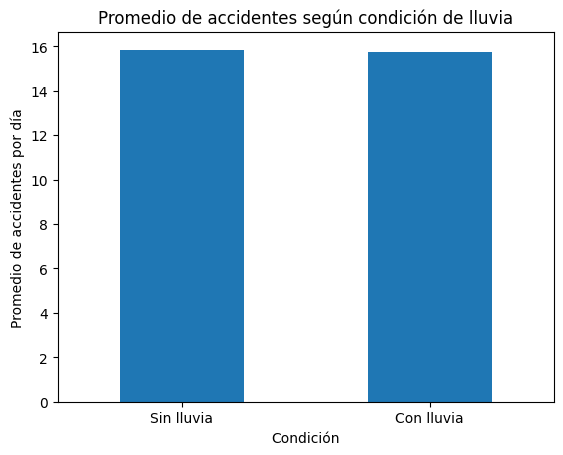

In [55]:
import matplotlib.pyplot as plt

promedio_accidentes = datos_integrados.groupby("LLUVIA")["ACCIDENTES"].mean()

promedio_accidentes.index = ["Sin lluvia", "Con lluvia"]

promedio_accidentes.plot(
    kind="bar",
    title="Promedio de accidentes según condición de lluvia"
)

plt.xlabel("Condición")
plt.ylabel("Promedio de accidentes por día")
plt.xticks(rotation=0)
plt.show()

7.2 Comparendos según lluvia

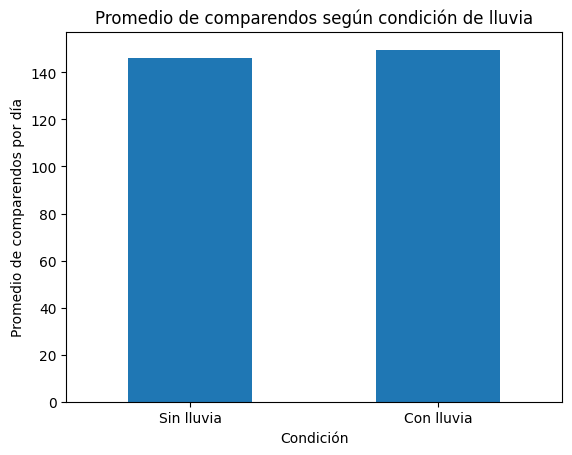

In [56]:
promedio_comparendos = datos_integrados.groupby("LLUVIA")["COMPARENDOS"].mean()

promedio_comparendos.index = ["Sin lluvia", "Con lluvia"]

promedio_comparendos.plot(
    kind="bar",
    title="Promedio de comparendos según condición de lluvia"
)

plt.xlabel("Condición")
plt.ylabel("Promedio de comparendos por día")
plt.xticks(rotation=0)
plt.show()

7.3 Precipitación y accidentes

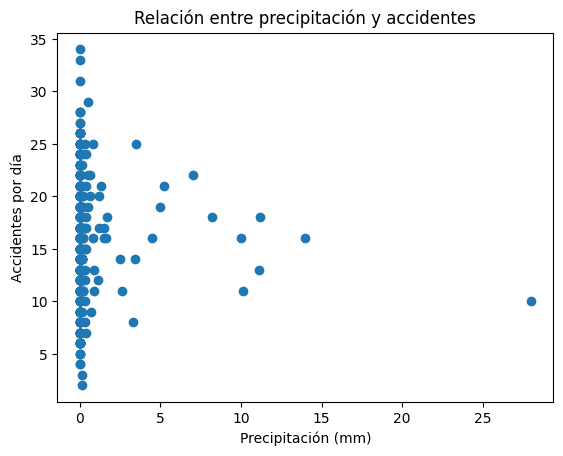

In [57]:
plt.scatter(
    datos_integrados["PRECIPITACION_MM"],
    datos_integrados["ACCIDENTES"]
)

plt.title("Relación entre precipitación y accidentes")
plt.xlabel("Precipitación (mm)")
plt.ylabel("Accidentes por día")
plt.show()

8. Conclusiones

A partir del análisis realizado sobre los accidentes de tránsito, la precipitación y los comparendos registrados en Barranquilla, se obtuvieron las siguientes conclusiones:

- Durante el período común analizado se registraron 9.566 accidentes y 88.639 comparendos.
- El promedio de accidentes fue de 15,85 por día en días sin lluvia y de 15,77 en días con lluvia.
- El promedio de comparendos fue de 146,31 por día en días sin lluvia y de 149,63 en días con lluvia.
- En los datos analizados no se observa una diferencia importante en el promedio diario de accidentes entre días con lluvia y días sin lluvia.
- La relación entre precipitación y accidentes debe interpretarse con precaución, ya que estos resultados muestran una asociación descriptiva y no permiten afirmar que la lluvia sea la causa de los accidentes.
- La integración de los tres datasets permitió analizar conjuntamente las condiciones de precipitación, los accidentes y los comparendos registrados por día.

In [4]:
import pandas as pd

# Cargar datasets
accidentes = pd.read_csv("../dataset/Accidentalidad_en_Barranquilla_20260830.csv")
precipitacion = pd.read_csv("../dataset/precipitacion_barranquilla.csv")
comparendos = pd.read_csv("../dataset/comparendos_Barranquilla.csv")

In [5]:
print("ACCIDENTES")
print(accidentes.columns.tolist())

print("\nPRECIPITACIÓN")
print(precipitacion.columns.tolist())

print("\nCOMPARENDOS")
print(comparendos.columns.tolist())

ACCIDENTES
['FECHA_ACCIDENTE', 'HORA_ACCIDENTE', 'GRAVEDAD_ACCIDENTE', 'CLASE_ACCIDENTE', 'SITIO_EXACTO_ACCIDENTE', 'CANT_HERIDOS_EN _SITIO_ACCIDENTE', 'CANT_MUERTOS_EN _SITIO_ACCIDENTE', 'CANTIDAD_ACCIDENTES', 'AÑO_ACCIDENTE', 'MES_ACCIDENTE', 'DIA_ACCIDENTE']

PRECIPITACIÓN
['codigoestacion', 'codigosensor', 'fechaobservacion', 'valorobservado', 'nombreestacion', 'departamento', 'municipio', 'zonahidrografica', 'latitud', 'longitud', 'descripcionsensor', 'unidadmedida']

COMPARENDOS
['fecha_comparendo', 'COD_INFRACCION', 'DESC_INFRACCION', 'TIPO_INFRACCION', 'SERVICIO_VEHICULO_INFRACTOR', 'CLASE_VEHICULO_INFRACTOR', 'CANTIDAD_INFRACCIONES', 'Tipo Camara', 'Camara_y_direccion']


In [6]:
print("Accidentes:")
display(accidentes.head())

print("Precipitación:")
display(precipitacion.head())

print("Comparendos:")
display(comparendos.head())

Accidentes:


,FECHA_ACCIDENTE,HORA_ACCIDENTE,GRAVEDAD_ACCIDENTE,CLASE_ACCIDENTE,SITIO_EXACTO_ACCIDENTE,CANT_HERIDOS_EN _SITIO_ACCIDENTE,CANT_MUERTOS_EN _SITIO_ACCIDENTE,CANTIDAD_ACCIDENTES,AÑO_ACCIDENTE,MES_ACCIDENTE,DIA_ACCIDENTE
0,2018-01-01T00:00:00.000,01:30:00:am,Con heridos,Atropello,CL 87 9H 24,1.0,NaN,1,2018,January,Mon
1,2018-01-01T00:00:00.000,02:00:00:pm,Solo daños,Choque,CL 110 CR 46,NaN,NaN,1,2018,January,Mon
2,2018-01-01T00:00:00.000,04:00:00:am,Solo daños,Choque,AV CIRCUNVALAR CR 9G,NaN,NaN,1,2018,January,Mon
3,2018-01-01T00:00:00.000,04:30:00:am,Solo daños,Choque,CLLE 72 CRA 29,NaN,NaN,1,2018,January,Mon
4,2018-01-01T00:00:00.000,05:20:00:pm,Solo daños,Choque,VIA 40 CALLE 75,NaN,NaN,1,2018,January,Mon


Precipitación:


,codigoestacion,codigosensor,fechaobservacion,valorobservado,nombreestacion,departamento,municipio,zonahidrografica,latitud,longitud,descripcionsensor,unidadmedida
0,29004520,240,2019-06-07T13:30:00.000,0.2,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm
1,29004520,240,2019-08-03T10:30:00.000,0.0,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm
2,29004520,240,2018-09-03T07:40:00.000,0.0,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm
3,29004520,240,2017-12-14T16:20:00.000,0.0,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm
4,29004520,240,2017-11-08T07:20:00.000,0.0,ESCUELA NAVAL BARRANQUILLA - AUT,ATLANTICO,BARRANQUILLA,BAJO MAGDALENA,11.006389,-74.785,Precipitacion,mm


Comparendos:


,fecha_comparendo,COD_INFRACCION,DESC_INFRACCION,TIPO_INFRACCION,SERVICIO_VEHICULO_INFRACTOR,CLASE_VEHICULO_INFRACTOR,CANTIDAD_INFRACCIONES,Tipo Camara,Camara_y_direccion
0,2018 Jan 01 12:00:00 AM,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,AUTOMOVIL,4,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 31
1,2018 Jan 01 12:00:00 AM,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,CAMIONETA,2,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 31
2,2018 Jan 01 12:00:00 AM,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,CAMIONETA,1,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 31
3,2018 Jan 01 12:00:00 AM,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,AUTOMOVIL,2,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 9G
4,2018 Jan 01 12:00:00 AM,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,CAMIONETA,3,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 9G


In [7]:
# Convertir las fechas al mismo formato: solo fecha

accidentes["FECHA"] = pd.to_datetime(
    accidentes["FECHA_ACCIDENTE"],
    errors="coerce"
).dt.date

precipitacion["FECHA"] = pd.to_datetime(
    precipitacion["fechaobservacion"],
    errors="coerce"
).dt.date

comparendos["FECHA"] = pd.to_datetime(
    comparendos["fecha_comparendo"],
    errors="coerce"
).dt.date

C:\Users\Loren\AppData\Local\Temp\ipykernel_20212\4090814184.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  comparendos["FECHA"] = pd.to_datetime(


In [8]:
accidentes_dia = accidentes.groupby("FECHA").agg(
    ACCIDENTES=("CANTIDAD_ACCIDENTES", "sum"),
    GRAVEDAD_ACCIDENTE=("GRAVEDAD_ACCIDENTE", lambda x: x.mode()[0] if not x.mode().empty else "Sin dato"),
    CLASE_ACCIDENTE=("CLASE_ACCIDENTE", lambda x: x.mode()[0] if not x.mode().empty else "Sin dato")
).reset_index()

display(accidentes_dia.head())

,FECHA,ACCIDENTES,GRAVEDAD_ACCIDENTE,CLASE_ACCIDENTE
0,2018-01-01,7,Solo daños,Choque
1,2018-01-02,11,Solo daños,Choque
2,2018-01-03,12,Solo daños,Choque
3,2018-01-04,16,Solo daños,Choque
4,2018-01-05,12,Solo daños,Choque


In [9]:
precipitacion_dia = precipitacion.groupby("FECHA").agg(
    PRECIPITACION_MM=("valorobservado", "sum")
).reset_index()

precipitacion_dia["LLUVIA"] = precipitacion_dia["PRECIPITACION_MM"].apply(
    lambda x: "Sí" if x > 0 else "No"
)

display(precipitacion_dia.head())

,FECHA,PRECIPITACION_MM,LLUVIA
0,2016-12-31,0.0,No
1,2017-01-01,0.0,No
2,2017-01-02,0.0,No
3,2017-01-03,0.0,No
4,2017-01-04,0.0,No


In [10]:
comparendos_dia = comparendos.groupby("FECHA").agg(
    COMPARENDOS=("CANTIDAD_INFRACCIONES", "sum"),
    COD_INFRACCION=("COD_INFRACCION", lambda x: x.mode()[0] if not x.mode().empty else "Sin dato"),
    TIPO_INFRACCION=("TIPO_INFRACCION", lambda x: x.mode()[0] if not x.mode().empty else "Sin dato"),
    CLASE_VEHICULO_INFRACTOR=("CLASE_VEHICULO_INFRACTOR", lambda x: x.mode()[0] if not x.mode().empty else "Sin dato"),
    SERVICIO_VEHICULO_INFRACTOR=("SERVICIO_VEHICULO_INFRACTOR", lambda x: x.mode()[0] if not x.mode().empty else "Sin dato")
).reset_index()

display(comparendos_dia.head())

,FECHA,COMPARENDOS,COD_INFRACCION,TIPO_INFRACCION,CLASE_VEHICULO_INFRACTOR,SERVICIO_VEHICULO_INFRACTOR
0,2018-01-01,293,C29,TRÁNSITO,AUTOMOVIL,PARTICULAR
1,2018-01-02,347,C02,TRÁNSITO,AUTOMOVIL,PARTICULAR
2,2018-01-03,269,C02,TRÁNSITO,AUTOMOVIL,PARTICULAR
3,2018-01-04,253,C02,TRÁNSITO,AUTOMOVIL,PARTICULAR
4,2018-01-05,317,C02,TRÁNSITO,AUTOMOVIL,PARTICULAR


In [11]:
dataset_integrado = accidentes_dia.merge(
    precipitacion_dia,
    on="FECHA",
    how="outer"
).merge(
    comparendos_dia,
    on="FECHA",
    how="outer"
)

dataset_integrado = dataset_integrado.sort_values("FECHA").reset_index(drop=True)

display(dataset_integrado.head(10))

,FECHA,ACCIDENTES,GRAVEDAD_ACCIDENTE,CLASE_ACCIDENTE,PRECIPITACION_MM,LLUVIA,COMPARENDOS,COD_INFRACCION,TIPO_INFRACCION,CLASE_VEHICULO_INFRACTOR,SERVICIO_VEHICULO_INFRACTOR
0,2016-12-31,NaN,NaN,NaN,0.0,No,NaN,NaN,NaN,NaN,NaN
1,2017-01-01,NaN,NaN,NaN,0.0,No,NaN,NaN,NaN,NaN,NaN
2,2017-01-02,NaN,NaN,NaN,0.0,No,NaN,NaN,NaN,NaN,NaN
3,2017-01-03,NaN,NaN,NaN,0.0,No,NaN,NaN,NaN,NaN,NaN
4,2017-01-04,NaN,NaN,NaN,0.0,No,NaN,NaN,NaN,NaN,NaN
5,2017-01-05,NaN,NaN,NaN,1.0,Sí,NaN,NaN,NaN,NaN,NaN
6,2017-01-06,NaN,NaN,NaN,0.0,No,NaN,NaN,NaN,NaN,NaN
7,2017-01-07,NaN,NaN,NaN,0.0,No,NaN,NaN,NaN,NaN,NaN
8,2017-01-08,NaN,NaN,NaN,0.0,No,NaN,NaN,NaN,NaN,NaN
9,2017-01-09,NaN,NaN,NaN,0.0,No,NaN,NaN,NaN,NaN,NaN


In [12]:
print("Filas y columnas:", dataset_integrado.shape)

print("\nColumnas:")
for columna in dataset_integrado.columns:
    print("-", columna)

Filas y columnas: (3452, 11)

Columnas:
- FECHA
- ACCIDENTES
- GRAVEDAD_ACCIDENTE
- CLASE_ACCIDENTE
- PRECIPITACION_MM
- LLUVIA
- COMPARENDOS
- COD_INFRACCION
- TIPO_INFRACCION
- CLASE_VEHICULO_INFRACTOR
- SERVICIO_VEHICULO_INFRACTOR


In [14]:
ruta_salida = "../dataset/dataset_integrado.xlsx"

dataset_integrado.to_excel(
    ruta_salida,
    index=False
)

print("✅ Excel integrado creado correctamente:")
print(ruta_salida)

✅ Excel integrado creado correctamente:
../dataset/dataset_integrado.xlsx
